In [18]:
# ============================================================================
# IMPORTAR LIBRERÍAS
# ============================================================================

import zipfile
import os
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, accuracy_score,
                            precision_score, recall_score, f1_score,
                            classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam

from google.colab import drive

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [19]:
# ============================================================================
# 1. CARGAR DATASET
# ============================================================================

print("\n" + "="*80)
print("1. CARGANDO DATASET")
print("="*80)

# Montar Google Drive
drive.mount('/content/drive')

# AJUSTAR ESTAS RUTAS A TU GOOGLE DRIVE
file_path = '/content/drive/My Drive/Redes Neuronales/Colab Notebooks/Entrega 2/Train.zip'
extract_path = '/content/drive/My Drive/Redes Neuronales/Colab Notebooks/Entrega 2/Auxiliar5'

# Extraer ZIP
with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print(f"✓ Dataset extraído: {extract_path}")

base_dir = '/content/drive/My Drive/Redes Neuronales/Colab Notebooks/Entrega 2/Auxiliar5/Train'


1. CARGANDO DATASET
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Dataset extraído: /content/drive/My Drive/Redes Neuronales/Colab Notebooks/Entrega 2/Auxiliar5


In [20]:
# ============================================================================
# 2. EXPLORAR DATASET
# ============================================================================

print("\n" + "="*80)
print("2. EXPLORANDO DATASET")
print("="*80)

# Obtener clases (alfabético automáticamente por sorted)
class_folders = sorted([folder for folder in os.listdir(base_dir)
                        if os.path.isdir(os.path.join(base_dir, folder))])

print(f"\n✓ Número de clases: {len(class_folders)}")
print(f"✓ Orden alfabético: {class_folders}")

# Cargar imágenes
images_dict = {}
dataset_stats = []

for class_folder in class_folders:
    class_path = os.path.join(base_dir, class_folder)
    image_files = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    images_dict[class_folder] = []

    for image_file in image_files:
        try:
            img = Image.open(os.path.join(class_path, image_file)).convert('RGB')
            images_dict[class_folder].append(img)
        except Exception as e:
            print(f"Error: {e}")

    dataset_stats.append({
        'Class': class_folder,
        'Images': len(images_dict[class_folder])
    })

df_stats = pd.DataFrame(dataset_stats)
print("\n" + df_stats.to_string(index=False))
print(f"\n✓ Total: {df_stats['Images'].sum()} imágenes")


2. EXPLORANDO DATASET

✓ Número de clases: 3
✓ Orden alfabético: ['skoda', 'toyota', 'volkswagen']

     Class  Images
     skoda     236
    toyota     306
volkswagen     330

✓ Total: 872 imágenes


In [21]:
# ============================================================================
# 3. PREPROCESAMIENTO
# ============================================================================

print("\n" + "="*80)
print("3. PREPROCESAMIENTO")
print("="*80)

IMG_SIZE = 128

# Redimensionar
for class_folder in class_folders:
    images_dict[class_folder] = [img.resize((IMG_SIZE, IMG_SIZE))
                                  for img in images_dict[class_folder]]

# Split 70/15/15
train_val_dict, test_dict = {}, {}

for class_name, images in images_dict.items():
    train_val, test_imgs = train_test_split(images, test_size=0.15, random_state=42)
    train_val_dict[class_name] = train_val
    test_dict[class_name] = test_imgs

train_dict, val_dict = {}, {}

for class_name, images in train_val_dict.items():
    train_imgs, val_imgs = train_test_split(images, test_size=0.15/(1-0.15), random_state=42)
    train_dict[class_name] = train_imgs
    val_dict[class_name] = val_imgs

# Recopilar datos
x_train, y_train = [], []
x_val, y_val = [], []
x_test, y_test = [], []

for class_name in class_folders:
    x_train.extend(train_dict[class_name])
    y_train.extend([class_name] * len(train_dict[class_name]))

    x_val.extend(val_dict[class_name])
    y_val.extend([class_name] * len(val_dict[class_name]))

    x_test.extend(test_dict[class_name])
    y_test.extend([class_name] * len(test_dict[class_name]))

# Normalizar
def imglist_to_array(img_list):
    return np.stack([np.array(img, dtype='float32') / 255.0 for img in img_list])

X_train = imglist_to_array(x_train)
X_val = imglist_to_array(x_val)
X_test = imglist_to_array(x_test)

print(f"\n✓ X_train: {X_train.shape}")
print(f"✓ X_val: {X_val.shape}")
print(f"✓ X_test: {X_test.shape}")


3. PREPROCESAMIENTO

✓ X_train: (608, 128, 128, 3)
✓ X_val: (132, 128, 128, 3)
✓ X_test: (132, 128, 128, 3)


In [22]:
# ============================================================================
# 4. LABEL ENCODING (CRÍTICO PARA MATRIZ CORRECTA)
# ============================================================================

print("\n" + "="*80)
print("4. LABEL ENCODING (ORDEN ALFABÉTICO)")
print("="*80)

# LabelEncoder mantiene orden alfabético
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

# Verificar mapeo (CRÍTICO)
print(f"\n✓ Número de clases: {num_classes}")
print("\n📋 MAPEO ÍNDICE → CLASE (alfabético):")
for idx, clase in enumerate(label_encoder.classes_):
    print(f"  {idx}: {clase}")

# One-Hot Encoding
y_train_cat = to_categorical(y_train_encoded, num_classes)
y_val_cat = to_categorical(y_val_encoded, num_classes)
y_test_cat = to_categorical(y_test_encoded, num_classes)

print(f"\n✓ One-hot shapes: {y_train_cat.shape}, {y_val_cat.shape}, {y_test_cat.shape}")


4. LABEL ENCODING (ORDEN ALFABÉTICO)

✓ Número de clases: 3

📋 MAPEO ÍNDICE → CLASE (alfabético):
  0: skoda
  1: toyota
  2: volkswagen

✓ One-hot shapes: (608, 3), (132, 3), (132, 3)


In [23]:
# ============================================================================
# 5. DATA AUGMENTATION
# ============================================================================

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(X_train)

In [24]:
# ============================================================================
# 6. CONSTRUCCIÓN DEL MODELO
# ============================================================================

print("\n" + "="*80)
print("6. MODELO CNN")
print("="*80)

def build_model(input_shape, num_classes):
    model = models.Sequential([
        # Bloque 1
        layers.Conv2D(32, (3,3), activation='relu',
                     kernel_regularizer=regularizers.l2(0.001),
                     input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),

        # Bloque 2
        layers.Conv2D(64, (3,3), activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),

        # Dense
        layers.Flatten(),
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model((IMG_SIZE, IMG_SIZE, 3), num_classes)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Modelo compilado")


6. MODELO CNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✓ Modelo compilado


In [25]:
# ============================================================================
# 7. ENTRENAMIENTO
# ============================================================================

print("\n" + "="*80)
print("7. ENTRENAMIENTO")
print("="*80)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                      min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1)
]

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Entrenamiento completado")


7. ENTRENAMIENTO


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.3811 - loss: 12.2771 - val_accuracy: 0.3712 - val_loss: 2.8230 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.3994 - loss: 3.2358 - val_accuracy: 0.4167 - val_loss: 2.6668 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.4086 - loss: 1.8182 - val_accuracy: 0.4015 - val_loss: 5.4582 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.4864 - loss: 1.7042 - val_accuracy: 0.4545 - val_loss: 4.4207 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.5026 - loss: 1.6364 - val_accuracy: 0.4091 - val_loss: 5.0464 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5824 - loss: 1.5212 - val_accuracy: 0.5000 - val_loss: 3.9612 - learning_rate: 0.0010
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5675 - loss: 1.5741
Epoch 7: 

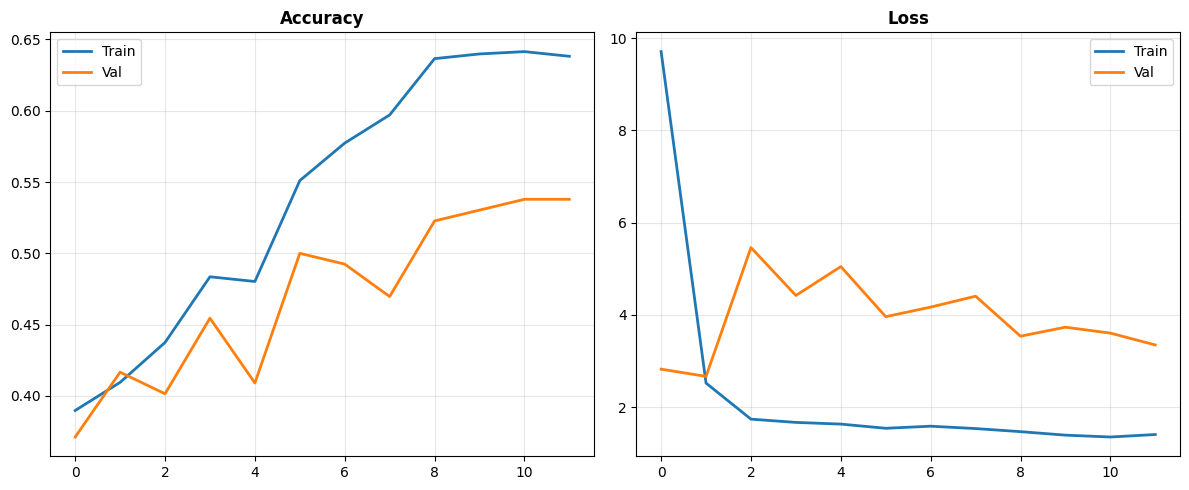

In [26]:
# ============================================================================
# 8. CURVAS DE ENTRENAMIENTO
# ============================================================================

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val', linewidth=2)
    ax1.set_title('Accuracy', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'], label='Train', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val', linewidth=2)
    ax2.set_title('Loss', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history)

In [27]:
# ============================================================================
# 9. MATRIZ DE CONFUSIÓN (CORREGIDA - DIAGONAL VISIBLE)
# ============================================================================

print("\n" + "="*80)
print("9. MATRIZ DE CONFUSIÓN (CORREGIDA)")
print("="*80)

# Hacer predicciones
y_pred_proba = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_proba, axis=1)

# CRÍTICO: Usar y_test_encoded (NO y_test_cat)
y_true_classes = y_test_encoded

print(f"\n✓ y_pred_classes shape: {y_pred_classes.shape}")
print(f"✓ y_true_classes shape: {y_true_classes.shape}")
print(f"✓ Predicted range: [{y_pred_classes.min()}, {y_pred_classes.max()}]")
print(f"✓ True range: [{y_true_classes.min()}, {y_true_classes.max()}]")

# Verificar distribución
print("\n📊 Distribución de predicciones:")
unique_pred, counts_pred = np.unique(y_pred_classes, return_counts=True)
for cls, cnt in zip(unique_pred, counts_pred):
    print(f"  Clase {cls} ({label_encoder.classes_[cls]}): {cnt} predicciones")

# Generar matriz de confusión
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Verificar diagonal
diagonal_sum = np.trace(conf_matrix)
total_sum = conf_matrix.sum()
accuracy_from_cm = diagonal_sum / total_sum

print(f"\n✓ Diagonal sum: {diagonal_sum}/{total_sum}")
print(f"✓ Accuracy from CM: {accuracy_from_cm*100:.2f}%")

# Verificación crítica
if diagonal_sum > total_sum * 0.5:
    print("MATRIZ CORRECTA: Valores en diagonal")
else:
    print("ADVERTENCIA: Problema en matriz")


9. MATRIZ DE CONFUSIÓN (CORREGIDA)

✓ y_pred_classes shape: (132,)
✓ y_true_classes shape: (132,)
✓ Predicted range: [0, 2]
✓ True range: [0, 2]

📊 Distribución de predicciones:
  Clase 0 (skoda): 5 predicciones
  Clase 1 (toyota): 87 predicciones
  Clase 2 (volkswagen): 40 predicciones

✓ Diagonal sum: 59/132
✓ Accuracy from CM: 44.70%
ADVERTENCIA: Problema en matriz



10. Visualizando matriz...


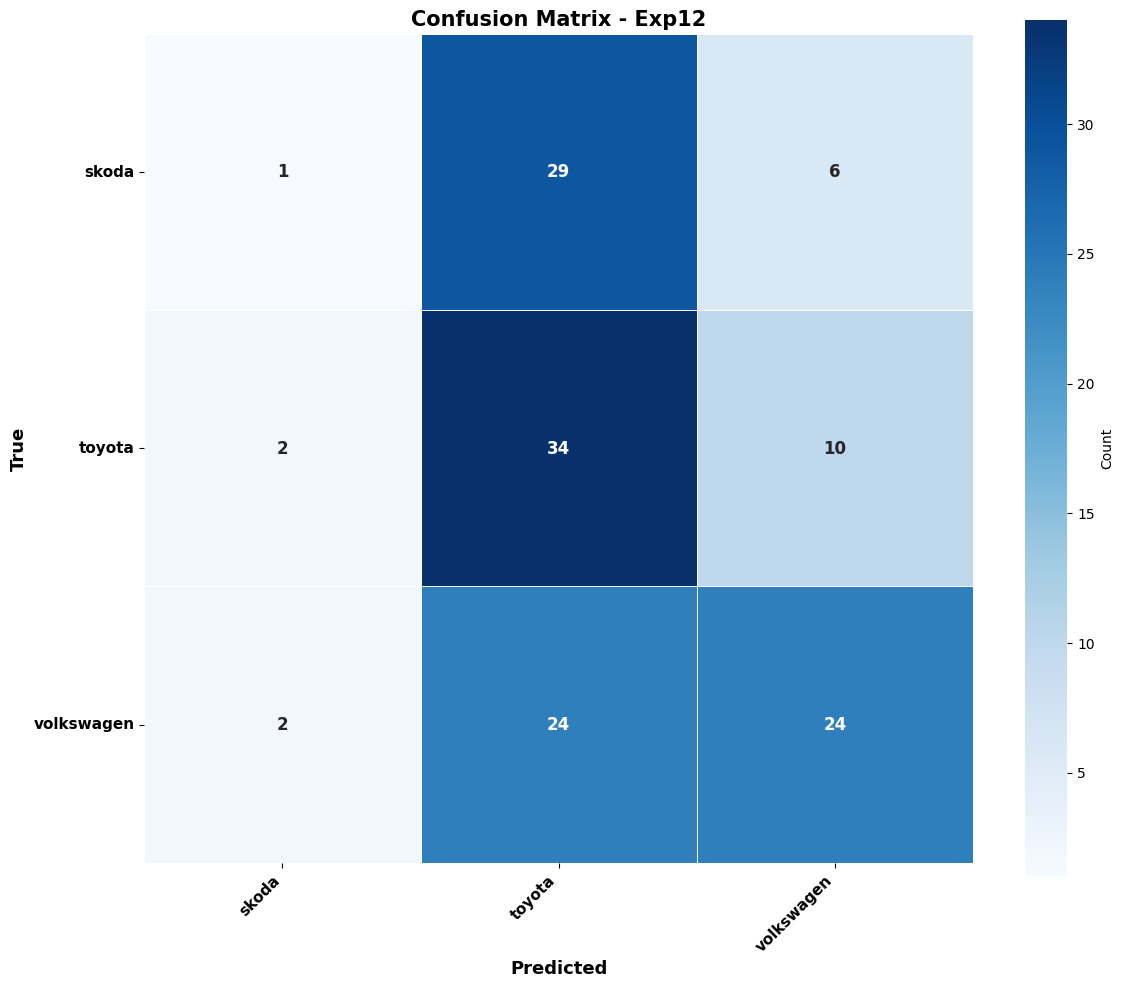

In [28]:
# ============================================================================
# 10. VISUALIZACIÓN DE MATRIZ (ESTILO IMAGEN DE REFERENCIA)
# ============================================================================

print("\n10. Visualizando matriz...")

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(conf_matrix,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            square=True,
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 12, 'fontweight': 'bold'},
            cbar_kws={'label': 'Count'},
            ax=ax)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.yticks(rotation=0, fontsize=11, fontweight='bold')
plt.xlabel('Predicted', fontsize=13, fontweight='bold')
plt.ylabel('True', fontsize=13, fontweight='bold')
plt.title('Confusion Matrix - Exp12', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# ============================================================================
# 11. ANÁLISIS POR CLASE
# ============================================================================

print("\n" + "="*80)
print("11. ANÁLISIS POR CLASE")
print("="*80)

print(f"\n{'Clase':<15} {'Correctas':>10} {'Total':>8} {'Accuracy':>10}")
print("-" * 50)

for i in range(num_classes):
    clase = label_encoder.classes_[i]
    correct = conf_matrix[i, i]
    total = conf_matrix[i, :].sum()
    acc = correct / total if total > 0 else 0
    print(f"{clase:<15} {correct:>10} {total:>8} {acc:>9.2%}")


11. ANÁLISIS POR CLASE

Clase            Correctas    Total   Accuracy
--------------------------------------------------
skoda                    1       36     2.78%
toyota                  34       46    73.91%
volkswagen              24       50    48.00%


In [30]:
# ============================================================================
# 12. MÉTRICAS FINALES
# ============================================================================

print("\n" + "="*80)
print("12. MÉTRICAS GLOBALES")
print("="*80)

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

precision = precision_score(y_true_classes, y_pred_classes, average='macro')
recall = recall_score(y_true_classes, y_pred_classes, average='macro')
f1 = f1_score(y_true_classes, y_pred_classes, average='macro')

print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-Score (macro): {f1:.4f}")

# Classification report detallado
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_true_classes, y_pred_classes,
                          target_names=label_encoder.classes_,
                          digits=4))


12. MÉTRICAS GLOBALES

Test Accuracy: 44.70%
Test Loss: 2.4525
Precision (macro): 0.3969
Recall (macro): 0.4156
F1-Score (macro): 0.3645

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       skoda     0.2000    0.0278    0.0488        36
      toyota     0.3908    0.7391    0.5113        46
  volkswagen     0.6000    0.4800    0.5333        50

    accuracy                         0.4470       132
   macro avg     0.3969    0.4156    0.3645       132
weighted avg     0.4180    0.4470    0.3935       132



In [31]:
# ============================================================================
# RESUMEN FINAL
# ============================================================================

print("\n" + "="*80)
print("="*80)
print(f"""
Dataset: {df_stats['Images'].sum()} imágenes, {num_classes} clases
Splits: {len(X_train)}/{len(X_val)}/{len(X_test)}
Test Accuracy: {test_acc*100:.2f}%
Matriz diagonal: {diagonal_sum}/{total_sum} predicciones correctas
""")
print("="*80)



Dataset: 872 imágenes, 3 clases
Splits: 608/132/132
Test Accuracy: 44.70%
Matriz diagonal: 59/132 predicciones correctas

